<a href="https://colab.research.google.com/github/carolineb3/deep-learning-sentiment-analysis-imdb/blob/main/modeling-code/final-project-code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Customer Reviews Using Deep Learning
### MIS 548 - Final Project
**Angelika Namieta & Caroline Brady**

---

## Project Overview
Businesses receive massive volumes of customer feedback that cannot reasonably be reviewed at scale. This notebook builds and compares seven deep learning models across four architectural families for binary sentiment classification (positive / negative) on the IMDb Movie Reviews Dataset (50,000 reviews).

| Model | Family | Key Idea |
|---|---|---|
| **CNN (1D)** | CNN | Local phrase-level feature extraction |
| **TextCNN (Multi-Kernel)** | CNN | Multi-scale local features via parallel kernels |
| **LSTM** | RNN | Sequential context modeling |
| **GRU** | RNN | Faster sequential modeling |
| **LSTM + Attention** | RNN | Attentive sequential modeling with Bahdanau attention |
| **CNN-LSTM Hybrid** | Hybrid | Combined local (CNN) and sequential (LSTM) features |
| **DistilBERT** | Transformer | Pretrained contextual embeddings via transfer learning |

## Install & Import

In [ ]:
# Install Hugging Face transformers + kagglehub for data loading
!pip install transformers kagglehub[pandas-datasets] seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import nltk
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
import random
import seaborn as sns
from sklearn.metrics import accuracy_score

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cuda


## Data Loading & Exploration
The IMDb dataset is loaded directly from from Kaggle using `kagglehub`.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

print("Downloading IMDb dataset from Kaggle...")
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'lakshmi25npathi/imdb-dataset-of-50k-movie-reviews',
    'IMDB Dataset.csv'
)

# Convert string labels to binary integers (1 = positive, 0 = negative)
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Dataset shape:', df.shape)
print('\nLabel distribution:')
print(df['sentiment'].value_counts())
print('\nSample review:')
print(df['review'].iloc[0][:300], '...')
print('\nAverage review length (words):', df['review'].apply(lambda x: len(x.split())).mean().round(1))

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset shape: (50000, 3)

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

Average review length (words): 231.2


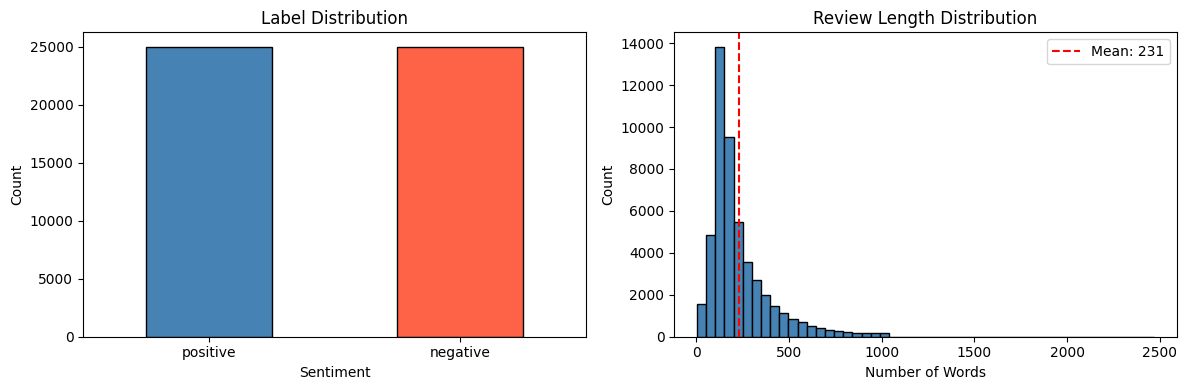

In [ ]:
# Visualize label balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

review_lengths = df['review'].apply(lambda x: len(x.split()))
axes[1].hist(review_lengths, bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].axvline(review_lengths.mean(), color='red', linestyle='--', label=f'Mean: {review_lengths.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Preprocessing (Shared by CNN & RNN)
All reviews go through the same pipeline before hitting any model: tokenize, lowercase, stem, build a vocab from the training set, then encode each review as a fixed-length integer sequence.

In [ ]:
# Tokenization & Stemming
stemmer = PorterStemmer()

def preprocess(text):
    """Tokenize, lowercase, stem, and keep only alphabetic tokens."""
    tokens = word_tokenize(text.lower())
    tokens = [stemmer.stem(w) for w in tokens if w.isalpha()]
    return tokens

print('Preprocessing reviews (this takes 2-3 minutes)...')
df['tokens'] = df['review'].apply(preprocess)
print('Done!')

# Show example
print('\nBefore:', df['review'].iloc[0][:100])
print('After: ', df['tokens'].iloc[0][:15])

Preprocessing reviews (this takes 2-3 minutes)...
Done!

Before: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The
After:  ['one', 'of', 'the', 'other', 'review', 'ha', 'mention', 'that', 'after', 'watch', 'just', 'oz', 'episod', 'you', 'be']


In [ ]:
# Encode to fixed-length integer sequences
MAX_LEN = 200  # practical sequence cap

def encode(tokens, vocab, max_len=MAX_LEN):
    ids = [vocab.get(t, 1) for t in tokens]              # map to int, UNK=1 if missing
    return ids[:max_len] + [0] * (max_len - len(ids))   # truncate or pad to max_len

In [ ]:
# Train / Test Split & PyTorch DataLoader
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Create copies
train_df = train_df.copy()
test_df = test_df.copy()

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

# Build Vocabulary from training data only (to prevent leakage)
train_tokens = [t for tokens in train_df['tokens'] for t in tokens]
vocab = {w: i+2 for i, (w, _) in enumerate(Counter(train_tokens).most_common())}
vocab['<PAD>'] = 0   # Padding token
vocab['<UNK>'] = 1   # Unknown word token

print(f'Vocabulary size: {len(vocab):,}')

# Encode training and test data
train_df['input_ids'] = train_df['tokens'].apply(lambda x: encode(x, vocab))
test_df['input_ids'] = test_df['tokens'].apply(lambda x: encode(x, vocab))

# Example of encoded sequence
print('\nEncoded example (first 20 ids):', train_df['input_ids'].iloc[0][:20])

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        return torch.tensor(self.encodings[idx]), torch.tensor(self.labels[idx])
    def __len__(self):
        return len(self.labels)

train_ds = TextDataset(train_df['input_ids'].tolist(), train_df['label'].tolist())
test_ds  = TextDataset(test_df['input_ids'].tolist(),  test_df['label'].tolist())

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

Train: 40,000 | Test: 10,000
Vocabulary size: 60,989

Encoded example (first 20 ids): [11, 1031, 12, 128, 1265, 340, 33, 1471, 154, 10, 41, 11, 14, 30, 4, 3162, 1419, 6, 55, 120]


## Training & Evaluation (shared across all models)

In [ ]:
def train_model(model, loader, epochs=5, lr=1e-3):
    """Train with BCEWithLogitsLoss (combines sigmoid + BCE)."""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X, y in loader:
            X, y = X.to(device), y.float().to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f'  Epoch {epoch+1}/{epochs} — Training Loss: {avg_loss:.4f}')

    return loss_history


def evaluate_model(model, loader):
    """Return predictions and true labels for classification report + confusion matrix."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = torch.sigmoid(model(X))
            preds += (out.cpu() > 0.5).int().tolist()
            trues += y.tolist()
    return trues, preds


def show_results(name, trues, preds, loss_history):
    """Print classification report and plot loss curve + confusion matrix."""
    print(f'\n====== {name} — Test Set Evaluation ======')
    print(classification_report(trues, preds, target_names=['Negative', 'Positive']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(name, fontsize=14, fontweight='bold')

    # Loss curve
    axes[0].plot(range(1, len(loss_history)+1), loss_history, marker='o', color='steelblue')
    axes[0].set_title('Training Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCE Loss')
    axes[0].grid(True)

    # Confusion matrix
    cm = confusion_matrix(trues, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.show()


# Store results for final comparison
results_summary = {}

## Model A: CNN (1D)

Each word index gets converted into a dense vector by the embedding layer. From there, 1D convolutional filters slide across the sequence. Global max-pooling then picks the strongest signal from the whole sequence before the final prediction.

In [ ]:
class SentimentCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, num_filters=128, kernel_size=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        # 1D conv: slides kernel_size-word windows over the sequence
        self.conv = nn.Conv1d(in_channels=emb_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, 1)  # Binary output → sigmoid in loss function

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)               # (batch, seq_len, emb_dim)
        x = x.permute(0, 2, 1)             # (batch, emb_dim, seq_len) — Conv1d expects channels first
        x = torch.relu(self.conv(x))        # (batch, num_filters, seq_len - kernel + 1)
        x = x.max(dim=2).values             # grab the strongest activation per filter
        x = self.dropout(x)
        return self.fc(x).squeeze(1)        #  single logit per review

vocab_size = len(vocab)
cnn_model = SentimentCNN(vocab_size)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

SentimentCNN(
  (embedding): Embedding(60989, 100, padding_idx=0)
  (conv): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 6,137,557


Training CNN...
  Epoch 1/5 — Training Loss: 0.5274
  Epoch 2/5 — Training Loss: 0.4019
  Epoch 3/5 — Training Loss: 0.3387
  Epoch 4/5 — Training Loss: 0.2843
  Epoch 5/5 — Training Loss: 0.2395

Total training time: 39.0s

====== CNN (1D) — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      5000
    Positive       0.86      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



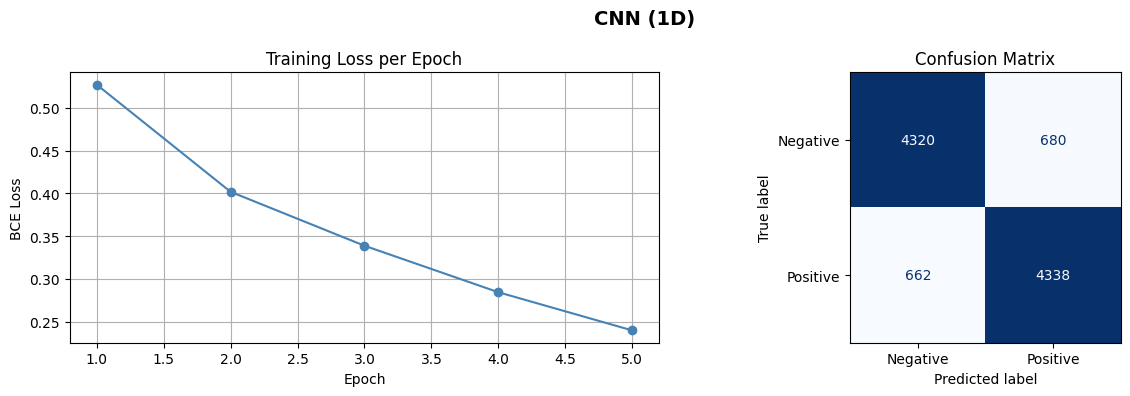

In [ ]:
print('Training CNN...')
t0 = time.time()
cnn_loss = train_model(cnn_model, train_loader, epochs=5)
cnn_time = time.time() - t0
print(f'\nTotal training time: {cnn_time:.1f}s')

cnn_true, cnn_pred = evaluate_model(cnn_model, test_loader)
show_results('CNN (1D)', cnn_true, cnn_pred, cnn_loss)

results_summary['CNN'] = {'accuracy': accuracy_score(cnn_true, cnn_pred), 'time': cnn_time}

## Model A+: TextCNN (Multi-Kernel)

The original Model A used a single fixed kernel with kernel_size=3. This model replaces it with three parallel ones (kernel sizes 2, 3, and 4), then each followed by global max-pooling. The three pooled vectors are concatenated before the final classifier.

**Note**: This improvement on our Model A was derived from the architecture from Kim (2014) *"Convolutional Neural Networks for Sentence Classification"* where multiple filter widths act as parallel n-gram detectors to let the model capture short phrase patterns at different scales at once.

In [ ]:
class TextCNN(nn.Module):
    """
    Multi-filter TextCNN (Kim, 2014).
    Three parallel Conv1d branches (kernel sizes 2, 3, 4) are each globally
    max-pooled and concatenated before the final binary classifier.
    """
    def __init__(self, vocab_size, emb_dim=100, num_filters=128,
                 kernel_sizes=(2, 3, 4), dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        # One Conv1d branch per kernel size — all share the same filter count
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=emb_dim, out_channels=num_filters,
                      kernel_size=k)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        # Concatenated pooled output has shape (batch, num_filters * len(kernel_sizes))
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)           # (batch, seq_len, emb_dim)
        x = x.permute(0, 2, 1)         # (batch, emb_dim, seq_len)

        # Apply each branch: conv → relu → global max pool → (batch, num_filters)
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]

        x = torch.cat(pooled, dim=1)    # (batch, num_filters * 3)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)    # (batch,)


textcnn_model = TextCNN(vocab_size=len(vocab))
print(textcnn_model)
total_params = sum(p.numel() for p in textcnn_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')
print(f'\nOriginal CNN parameters: 6,780,457')
print(f'Delta: +{total_params - 6_780_457:,} (two extra Conv1d branches + wider fc)')


TextCNN(
  (embedding): Embedding(60989, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)

Trainable parameters: 6,214,869

Original CNN parameters: 6,780,457
Delta: +-565,588 (two extra Conv1d branches + wider fc)


Training TextCNN (Multi-Kernel)...
  Epoch 1/5 — Training Loss: 0.4989
  Epoch 2/5 — Training Loss: 0.3701
  Epoch 3/5 — Training Loss: 0.3023
  Epoch 4/5 — Training Loss: 0.2440
  Epoch 5/5 — Training Loss: 0.2002

Total training time: 1391.0s

====== TextCNN (Multi-Kernel) — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.88      5000
    Positive       0.88      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



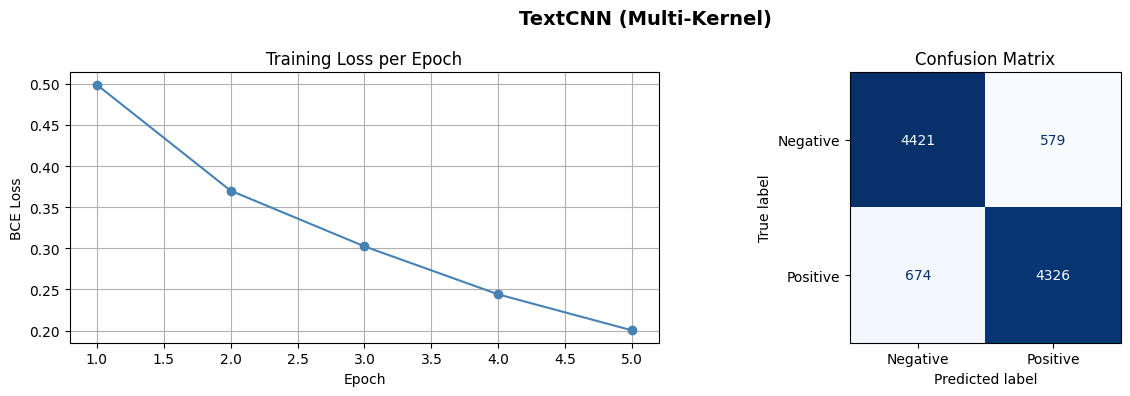


Original CNN accuracy:  86.58%
TextCNN accuracy:       87.47%


In [ ]:
print('Training TextCNN (Multi-Kernel)...')
t0 = time.time()
textcnn_loss = train_model(textcnn_model, train_loader, epochs=5)
textcnn_time = time.time() - t0
print(f'\nTotal training time: {textcnn_time:.1f}s')

textcnn_true, textcnn_pred = evaluate_model(textcnn_model, test_loader)
show_results('TextCNN (Multi-Kernel)', textcnn_true, textcnn_pred, textcnn_loss)

results_summary['TextCNN (Multi-Kernel)'] = {
    'accuracy': accuracy_score(textcnn_true, textcnn_pred),
    'time': textcnn_time
}
print(f"\nOriginal CNN accuracy:  {results_summary['CNN']['accuracy']:.2%}")
print(f"TextCNN accuracy:       {accuracy_score(textcnn_true, textcnn_pred):.2%}")

## Model B: LSTM

Unlike the CNN which only sees local windows, the LSTM reads the review word by word and builds up context as it goes. The three gates (input, forget, output) also help to handle the vanishing gradient problem that plain RNNs face. We've stacked two LSTM layers for more depth.

Training LSTM...
  Epoch 1/5 — Training Loss: 0.5057
  Epoch 2/5 — Training Loss: 0.3219
  Epoch 3/5 — Training Loss: 0.2459
  Epoch 4/5 — Training Loss: 0.1909
  Epoch 5/5 — Training Loss: 0.1394

Total training time: 55.8s

====== LSTM — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88      5000
    Positive       0.87      0.90      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



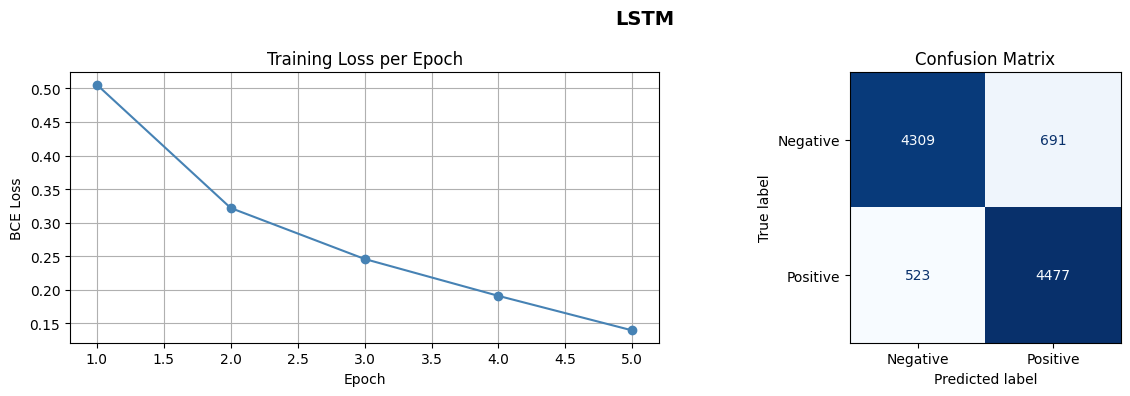

In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden_dim=128, model_type='lstm', dropout=0.3):
        super().__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        if model_type == 'lstm':
            self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True, dropout=dropout, num_layers=2)
        elif model_type == 'gru':
            self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True, dropout=dropout, num_layers=2)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq_len, emb_dim)
        out, _ = self.rnn(x)           # (batch, seq_len, hidden_dim)
        out = out.max(dim=1).values    # Global max pooling over sequence (avoids padding trap)
        out = self.dropout(out)
        return self.fc(out).squeeze(1)

# Train LSTM
print('Training LSTM...')
t0 = time.time()
lstm_model = SentimentRNN(vocab_size, model_type='lstm')
lstm_loss = train_model(lstm_model, train_loader, epochs=5)
lstm_time = time.time() - t0
print(f'\nTotal training time: {lstm_time:.1f}s')

lstm_true, lstm_pred = evaluate_model(lstm_model, test_loader)
show_results('LSTM', lstm_true, lstm_pred, lstm_loss)
results_summary['LSTM'] = {'accuracy': accuracy_score(lstm_true, lstm_pred), 'time': lstm_time}

## Model C: GRU

 GRU is a simpler version of LSTM, where it gets the same sequential context modeling done with two gates instead of three. This means it hasfewer parameters and faster convergence. We wanted to see how it compared against the LSTM Model B.

Training GRU...
  Epoch 1/5 — Training Loss: 0.4483
  Epoch 2/5 — Training Loss: 0.2794
  Epoch 3/5 — Training Loss: 0.2077
  Epoch 4/5 — Training Loss: 0.1421
  Epoch 5/5 — Training Loss: 0.0906

Total training time: 45.6s

====== GRU — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



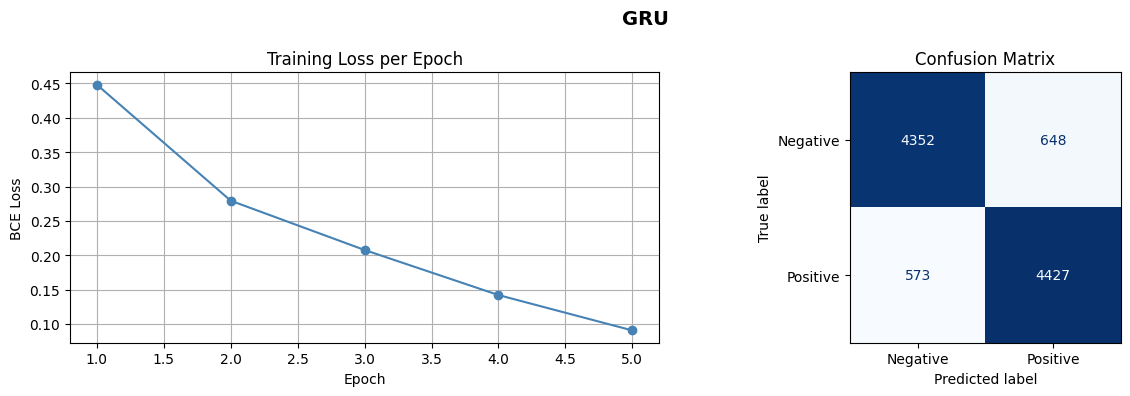

In [ ]:
# Train GRU
print('Training GRU...')
t0 = time.time()
gru_model = SentimentRNN(vocab_size, model_type='gru')
gru_loss = train_model(gru_model, train_loader, epochs=5)
gru_time = time.time() - t0
print(f'\nTotal training time: {gru_time:.1f}s')

gru_true, gru_pred = evaluate_model(gru_model, test_loader)
show_results('GRU', gru_true, gru_pred, gru_loss)
results_summary['GRU'] = {'accuracy': accuracy_score(gru_true, gru_pred), 'time': gru_time}

## Model D: LSTM + Attention

 We chose to add attention because the base LSTM condenses the whole review into its final hidden state, which means for a 200-word review the first words are less significant. Bahdanau attention fixes this by scoring every hidden state and computing a weighted sum so the model can look back at whichever words were the most important, regardless of where they appear.

 The attention weights are also returned so we can visualize which words the model focused on.

In [ ]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention over LSTM hidden states.
    Scores each time step with a single-layer MLP, normalises with softmax,
    and returns the weighted context vector plus the attention weight distribution.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden_states, mask):
        # hidden_states: (batch, seq_len, hidden_dim)
        energy  = torch.tanh(self.attn(hidden_states))   # (batch, seq_len, hidden_dim)
        scores  = self.v(energy).squeeze(2)              # (batch, seq_len)
        scores = scores.masked_fill(mask == 0, -1e9)    # Mask pads to prevent attention on padding
        weights = torch.softmax(scores, dim=1)           # (batch, seq_len)  — sum to 1
        # Weighted sum across the time dimension
        context = (weights.unsqueeze(2) * hidden_states).sum(dim=1)  # (batch, hidden_dim)
        return context, weights


class SentimentLSTMAttention(nn.Module):
    """
    2-layer LSTM with Bahdanau attention.
    Identical hyper-parameters to SentimentRNN (model_type='lstm') except the
    classifier receives the attention context vector instead of h_T.

    forward() returns:
        logits   — (batch,)  for BCEWithLogitsLoss
        weights  — (batch, seq_len)  attention distribution (optional visualisation)
    """
    def __init__(self, vocab_size, emb_dim=100, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm      = nn.LSTM(emb_dim, hidden_dim, num_layers=2,
                                 batch_first=True, dropout=dropout)
        self.attention = BahdanauAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        mask = (x != 0)                                         # (batch, seq_len), before embedding
        x = self.embedding(x)                                   # (batch, seq_len, emb_dim)
        hidden_states, _ = self.lstm(x)                         # (batch, seq_len, hidden_dim)
        context, weights = self.attention(hidden_states, mask)  # (batch, hidden_dim), (batch, seq_len)
        out = self.dropout(context)
        logits = self.fc(out).squeeze(1)                        # (batch,)
        return logits, weights


# Wrapper so train_model() / evaluate_model() (which expect a single tensor output) work unchanged
class LSTMAttentionWrapper(nn.Module):
    """Thin wrapper that discards attention weights for compatibility with train/evaluate utilities."""
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits


lstm_attn_base    = SentimentLSTMAttention(vocab_size=len(vocab))
lstm_attn_model   = LSTMAttentionWrapper(lstm_attn_base)

print(lstm_attn_base)
total_params = sum(p.numel() for p in lstm_attn_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

SentimentLSTMAttention(
  (embedding): Embedding(60989, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): BahdanauAttention(
    (attn): Linear(in_features=128, out_features=128, bias=True)
    (v): Linear(in_features=128, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 6,365,525


Training LSTM + Attention...
  Epoch 1/5 — Training Loss: 0.0456
  Epoch 2/5 — Training Loss: 0.0248
  Epoch 3/5 — Training Loss: 0.0171
  Epoch 4/5 — Training Loss: 0.0141
  Epoch 5/5 — Training Loss: 0.0119

Total training time: 63.0s

====== LSTM + Attention — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87      5000
    Positive       0.86      0.90      0.88      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



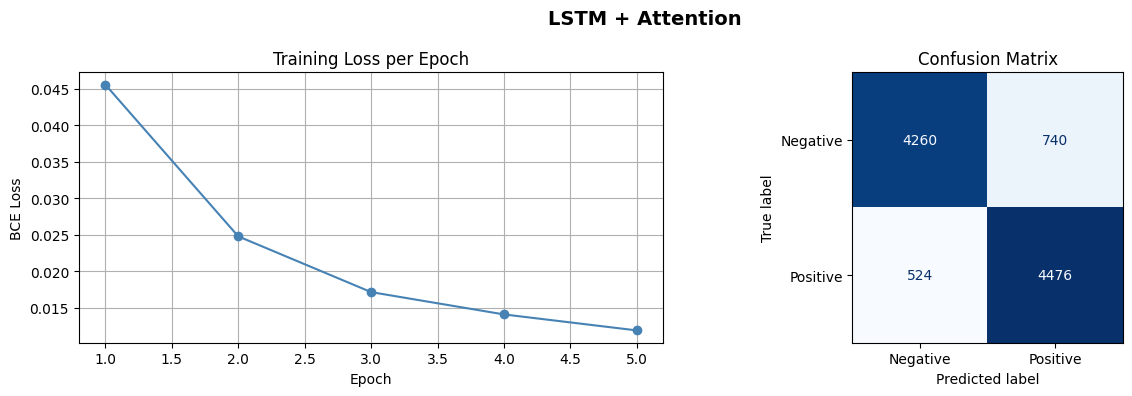


Base LSTM accuracy:         87.86%
LSTM+Attention accuracy:     87.36%


In [ ]:
print('Training LSTM + Attention...')
t0 = time.time()
lstm_attn_loss = train_model(lstm_attn_model, train_loader, epochs=5)
lstm_attn_time = time.time() - t0
print(f'\nTotal training time: {lstm_attn_time:.1f}s')

lstm_attn_true, lstm_attn_pred = evaluate_model(lstm_attn_model, test_loader)
show_results('LSTM + Attention', lstm_attn_true, lstm_attn_pred, lstm_attn_loss)

results_summary['LSTM + Attention'] = {
    'accuracy': accuracy_score(lstm_attn_true, lstm_attn_pred),
    'time': lstm_attn_time
}
print(f"\nBase LSTM accuracy:         {results_summary['LSTM']['accuracy']:.2%}")
print(f"LSTM+Attention accuracy:     {accuracy_score(lstm_attn_true, lstm_attn_pred):.2%}")

=== Attention visualisation: Positive review ===


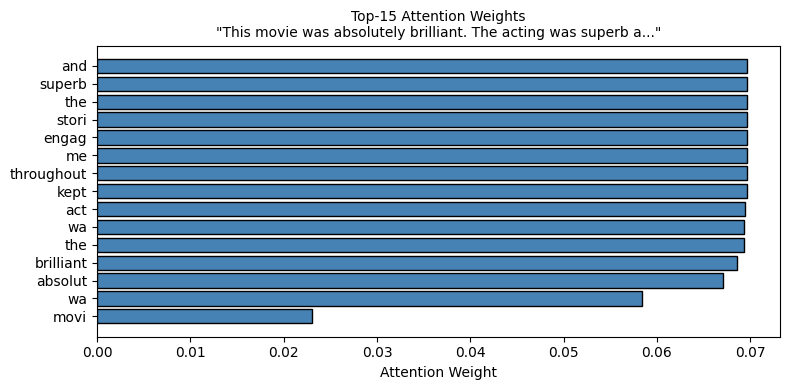

=== Attention visualisation: Negative review ===


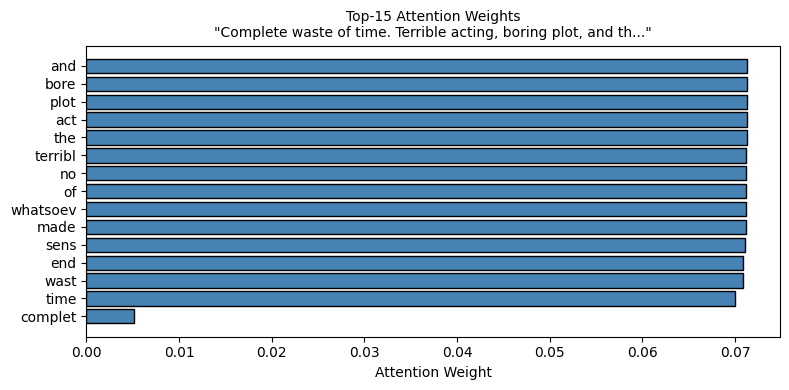

In [ ]:
# ── Attention Weight Visualisation ────────────────────────────────
# Shows which words the model weighted most heavily for a sample review.

def visualize_attention(base_model, review_text, vocab, max_len=MAX_LEN, top_n=15):
    """
    Tokenize a raw review string, run the LSTM+Attention model, and plot a
    horizontal bar chart of the top-N highest-weighted tokens.
    """
    base_model.eval()
    stemmer_local = PorterStemmer()

    tokens = [stemmer_local.stem(w) for w in word_tokenize(review_text.lower()) if w.isalpha()]
    ids    = encode(tokens, vocab, max_len)
    x      = torch.tensor([ids]).to(device)

    with torch.no_grad():
        _, weights = base_model(x)               # weights: (1, max_len)

    weights_np = weights.squeeze(0).cpu().numpy()  # (max_len,)

    # Pair each token with its attention weight
    token_weights = list(zip(tokens[:max_len], weights_np[:len(tokens)]))
    token_weights.sort(key=lambda x: x[1], reverse=True)
    top = token_weights[:top_n]

    words, scores = zip(*top)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(words)), scores, color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Attention Weight')
    ax.set_title(f'Top-{top_n} Attention Weights\n"{review_text[:60]}..."', fontsize=10)
    plt.tight_layout()
    plt.show()


# Example: visualise attention on a strongly positive and a strongly negative review
sample_pos = "This movie was absolutely brilliant. The acting was superb and the story kept me engaged throughout."
sample_neg = "Complete waste of time. Terrible acting, boring plot, and the ending made no sense whatsoever."

print("=== Attention visualisation: Positive review ===")
visualize_attention(lstm_attn_base, sample_pos, vocab)

print("=== Attention visualisation: Negative review ===")
visualize_attention(lstm_attn_base, sample_neg, vocab)

## Model E: CNN-LSTM Hybrid

CNNs are good at catching short phrases but struggle to order over long distances. LSTMs are the opposite because they're better at sequence structure but have to process raw embeddings.

The idea is to let the CNN compress the embedding sequence into higher-level local features first, then hand that compressed sequence to the LSTM.

We referenced Sorour et al. (2024) *WDE-CNN-LSTM architecture*.


In [ ]:
class SentimentCNNLSTM(nn.Module):
    """
    CNN-LSTM hybrid based on Sorour et al. (2024). CNN extracts local features first, then LSTM reads the compressed sequence.
    """
    def __init__(self, vocab_size, emb_dim=100, num_filters=128,
                 hidden_dim=128, kernel_size=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        # CNN stage: extract local features from embedding sequence
        self.conv    = nn.Conv1d(in_channels=emb_dim, out_channels=num_filters,
                                 kernel_size=kernel_size)

        # LSTM stage: model sequential dependencies over CNN feature maps
        # Input dim = num_filters (one feature vector per position from conv output)
        self.lstm    = nn.LSTM(input_size=num_filters, hidden_size=hidden_dim,
                               num_layers=2, batch_first=True, dropout=dropout)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)           # (batch, seq_len, emb_dim)
        x = x.permute(0, 2, 1)         # (batch, emb_dim, seq_len)  — Conv1d needs channels first

        x = torch.relu(self.conv(x))    # (batch, num_filters, seq_len - kernel_size + 1)

        # Restore sequence-first layout for LSTM
        x = x.permute(0, 2, 1)

        out, _ = self.lstm(x)           # (batch, seq_len', hidden_dim)
        out    = out.max(dim=1).values  # Global max pooling (avoids padding trap)
        return self.fc(out).squeeze(1)  # (batch,)


cnn_lstm_model = SentimentCNNLSTM(vocab_size=len(vocab))
print(cnn_lstm_model)
total_params = sum(p.numel() for p in cnn_lstm_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

SentimentCNNLSTM(
  (embedding): Embedding(60989, 100, padding_idx=0)
  (conv): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 6,401,749


Training CNN-LSTM Hybrid...
  Epoch 1/5 — Training Loss: 0.5133
  Epoch 2/5 — Training Loss: 0.3115
  Epoch 3/5 — Training Loss: 0.2271
  Epoch 4/5 — Training Loss: 0.1658
  Epoch 5/5 — Training Loss: 0.1153

Total training time: 65.3s

====== CNN-LSTM Hybrid — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.81      0.93      0.86      5000
    Positive       0.92      0.78      0.84      5000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



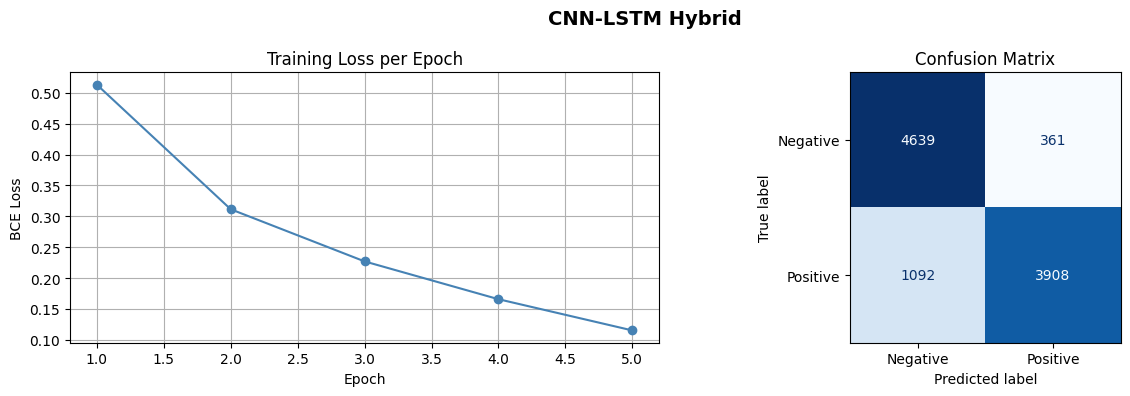

In [ ]:
print('Training CNN-LSTM Hybrid...')
t0 = time.time()
cnn_lstm_loss = train_model(cnn_lstm_model, train_loader, epochs=5)
cnn_lstm_time = time.time() - t0
print(f'\nTotal training time: {cnn_lstm_time:.1f}s')

cnn_lstm_true, cnn_lstm_pred = evaluate_model(cnn_lstm_model, test_loader)
show_results('CNN-LSTM Hybrid', cnn_lstm_true, cnn_lstm_pred, cnn_lstm_loss)

results_summary['CNN-LSTM Hybrid'] = {
    'accuracy': accuracy_score(cnn_lstm_true, cnn_lstm_pred),
    'time': cnn_lstm_time
}


## Model F: Fine-Tuned DistilBERT (Pretrained Transformer)

The other models start from scratch, but DistilBERT already knows English because it was pre-trained on 3.3 billion words. Here we just fine-tune the model on our IMDb data for 3 epochs to specialize it for sentiment. The self-attention mechanism lets every word attend to every other word at once, which is how it catches things that trip up the previous sequential models.

For preprocessing, instead of applying Porter stemming and encoding against our custom vocabulary, DistilBERT uses its own WordPiece subword tokenizer. Reviews are padded or truncated to 256 subword tokens, and an attention mask is generated to tell the model which positions are real tokens vs. padding.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

# Load DistilBERT tokenizer and model
# distilbert-base-uncased-finetuned-sst-2-english is already specialized for sentiment
# We use the base uncased model and fine-tune ourselves so you can see the process
BERT_MODEL = 'distilbert-base-uncased'
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

class BertDataset(Dataset):
    """Dataset that uses the DistilBERT subword tokenizer (replaces manual vocab)."""
    def __init__(self, texts, labels):
        # The tokenizer handles everything: subword splitting, special tokens, padding
        self.encodings = bert_tokenizer(
            texts, truncation=True, padding=True, max_length=256, return_tensors='pt'
        )
        self.labels = torch.tensor(labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]
    def __len__(self):
        return len(self.labels)

print('Tokenizing with DistilBERT tokenizer...')
bert_train_ds = BertDataset(train_df['review'].tolist(), train_df['label'].tolist())
bert_test_ds  = BertDataset(test_df['review'].tolist(),  test_df['label'].tolist())

bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True, num_workers=2)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=16, shuffle=False, num_workers=2)
print('Done!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing with DistilBERT tokenizer...
Done!


In [ ]:
# Load the pretrained model with a 2-class classification head on top
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
bert_model.to(device)

optimizer_bert = AdamW(bert_model.parameters(), lr=2e-5)  # Lower LR for fine-tuning

print('Fine-tuning DistilBERT (3 epochs)...')
bert_loss_history = []
t0 = time.time()

for epoch in range(3):
    bert_model.train()
    total_loss = 0
    for batch, labels in bert_train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)
        outputs = bert_model(**batch, labels=labels)
        outputs.loss.backward()
        optimizer_bert.step()
        optimizer_bert.zero_grad()
        total_loss += outputs.loss.item()
    avg = total_loss / len(bert_train_loader)
    bert_loss_history.append(avg)
    print(f'  Epoch {epoch+1}/3 — Training Loss: {avg:.4f}')

bert_time = time.time() - t0
print(f'\nTotal fine-tuning time: {bert_time:.1f}s')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT (3 epochs)...
  Epoch 1/3 — Training Loss: 0.2594
  Epoch 2/3 — Training Loss: 0.1539
  Epoch 3/3 — Training Loss: 0.0845

Total fine-tuning time: 2964.8s



====== DistilBERT (Fine-tuned) — Test Set Evaluation ======
              precision    recall  f1-score   support

    Negative       0.95      0.88      0.92      5000
    Positive       0.89      0.95      0.92      5000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



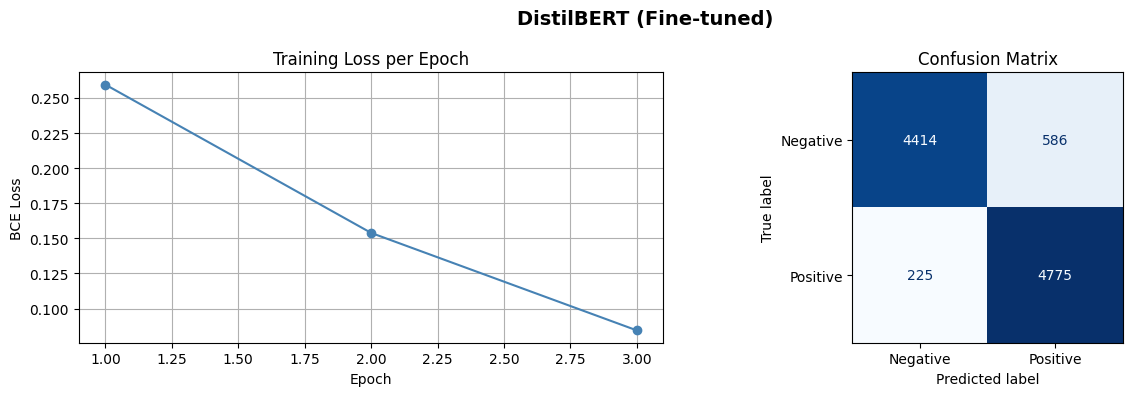

In [ ]:
# Evaluate DistilBERT
bert_model.eval()
bert_preds, bert_trues = [], []
with torch.no_grad():
    for batch, labels in bert_test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = bert_model(**batch).logits
        bert_preds += logits.argmax(dim=1).cpu().tolist()
        bert_trues += labels.tolist()

show_results('DistilBERT (Fine-tuned)', bert_trues, bert_preds, bert_loss_history)
results_summary['DistilBERT'] = {'accuracy': accuracy_score(bert_trues, bert_preds), 'time': bert_time}

## Final Model Comparison

Consolidated results across all seven models, drawn dynamically from results_summary populated during training.


=== All-Model Summary ===
                       Test Accuracy Training Time (s)
Model                                                 
CNN                           0.8658              39.0
LSTM                          0.8786              55.8
GRU                           0.8779              45.6
DistilBERT                    0.9189            2964.8
TextCNN (Multi-Kernel)        0.8747            1391.0
LSTM + Attention              0.8736              63.0
CNN-LSTM Hybrid               0.8547              65.3


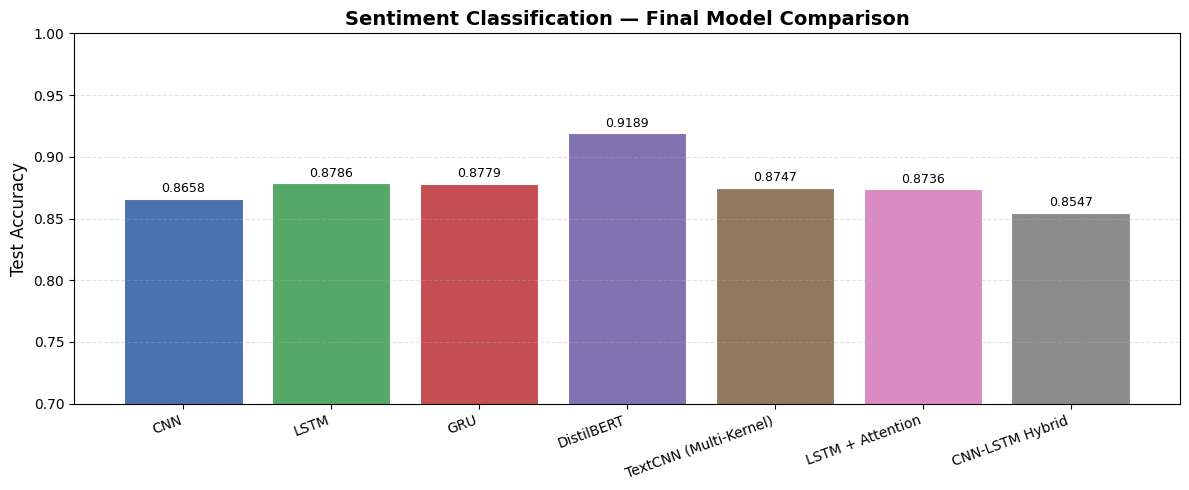

Chart saved as all_models_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Build final comparison dataframe from live training results.
# This cell should run only after all model training/evaluation cells complete.
expected_models = [
    'CNN',
    'LSTM',
    'GRU',
    'DistilBERT',
    'TextCNN (Multi-Kernel)',
    'LSTM + Attention',
    'CNN-LSTM Hybrid'
]

missing_models = [m for m in expected_models if m not in results_summary]
if missing_models:
    print('WARNING: The following models are missing from results_summary:', missing_models)
    print('Run the missing model training cells before using this table for the report or presentation.')

comparison_df = pd.DataFrame.from_dict(results_summary, orient='index')

# Enforce expected model order in the final dataframe
comparison_df = comparison_df.reindex([m for m in expected_models if m in comparison_df.index])

comparison_df = comparison_df.rename(columns={
    'accuracy': 'Test Accuracy',
    'time': 'Training Time (s)'
})
comparison_df = comparison_df[['Test Accuracy', 'Training Time (s)']]
comparison_df.index.name = 'Model'

print('\n=== All-Model Summary ===')
print(comparison_df.to_string(formatters={
    'Test Accuracy': lambda x: f'{x:.4f}',
    'Training Time (s)': lambda x: f'{x:.1f}'
}))

# Accuracy bar chart from live results
model_names = comparison_df.index.tolist()
accuracies = comparison_df['Test Accuracy'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2',
          '#937860', '#DA8BC3', '#8C8C8C'][:len(model_names)]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0.70, 1.00)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Sentiment Classification — Final Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as all_models_comparison.png')
